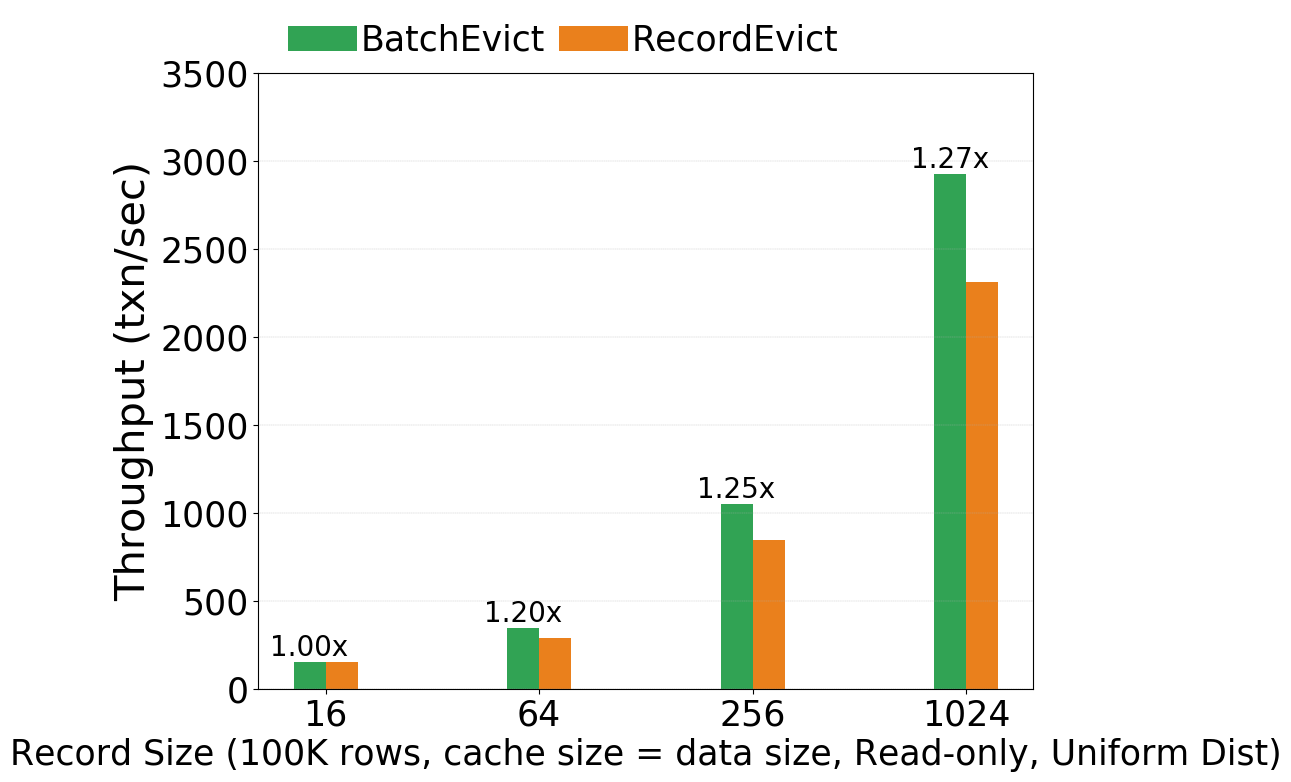

In [14]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from process_helper import select_color_idx

txtsize=30
ticksize=25

color_indices, line_colors = select_color_idx(4)
nemo_batch_evict_c = "#31a354"
nemo_record_evict_c =  "#ea801c"
# # page_retain_c = line_colors["BLUE"]
# page_evict_c = "#78c679"
# tt_retain_c = "#1f6f6f"
# tt_evict_c = "#54a1a1"

# nemo_batch_evict_label = "Nemo-BatchEvict"
# nemo_record_evict_label = "Nemo-RecordEvict"
nemo_batch_evict_label = "BatchEvict"
nemo_record_evict_label = "RecordEvict"

datadir = "../../output/"
exp_tuple_batch_evict = "exp_point_100m_batch"
exp_tuple_record_evict = "exp_point_100m_record"

# Load and prepare the data

data_tuple_batch = [json.loads(line) for line in open(datadir + exp_tuple_batch_evict + ".txt")]
df_tuple_batch = pd.DataFrame().from_records(data_tuple_batch).sort_values(by='g_record_size')

data_tuple_record = [json.loads(line) for line in open(datadir + exp_tuple_record_evict + ".txt")]
df_tuple_record = pd.DataFrame().from_records(data_tuple_record).sort_values(by='g_record_size')



fig, ax1 = plt.subplots(figsize=(10, 8))

bar_width = 0.15
indices = np.arange(len(data_tuple_batch))
offset = bar_width

# Bar chart for the primary data
batch_bars = ax1.bar(indices - offset/2 , df_tuple_batch["throughput_txn_per_sec"], bar_width, label=nemo_batch_evict_label, color=nemo_batch_evict_c)
record_bars = ax1.bar(indices + offset/2, df_tuple_record["throughput_txn_per_sec"], bar_width, label=nemo_record_evict_label, color=nemo_record_evict_c)

speedup = ((df_tuple_batch["throughput_txn_per_sec"] / 
           df_tuple_record["throughput_txn_per_sec"] ) )


for idx, (bar, gain) in enumerate(zip(batch_bars, speedup)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height,
            f'{gain:.2f}x',
            ha='center', va='bottom',
            fontsize=ticksize-5)


ax1.set_xticks(indices)
x_tick_num = df_tuple_batch["g_record_size"].astype(int)
x_tick_labels = x_tick_num

ax1.set_xticklabels(x_tick_labels, fontsize=ticksize)
# ax1.set_yticklabels(fontsize=ticksize)
ax1.tick_params(axis='y', labelsize=ticksize)

# ax1.set_xscale('log')
# ax1.set_yscale('log')
# ax1.set_ylim(50, 200000)
ax1.set_ylim(0, 3500)

ax1.set_ylabel("Throughput (txn/sec)", fontsize=txtsize)
# ax1.set_xlabel("Buffer Ratio (10GB, Write-heavy, Uniform Dist)", fontsize=txtsize)
ax1.set_xlabel("Record Size (100K rows, cache size = data size, Read-only, Uniform Dist)", fontsize=ticksize)
ax1.grid(axis='y', linestyle='--', linewidth=0.25)
# legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2, ncol=3, borderaxespad=0., handletextpad=0.4, labelspacing=0.2, columnspacing=0.5, frameon=False)

legend = ax1.legend(fontsize=ticksize, bbox_to_anchor=(0.02, 1, 1.1, .102), loc=2,
           ncol=3,borderaxespad=0., frameon=False,columnspacing=0.4, handletextpad=0.1)
# Legend
# ax1.legend(loc='upper left')

# plt.savefig("/home/hippo/Bonsai-private/paper/experiment/debug_eviction.pdf", bbox_inches='tight')




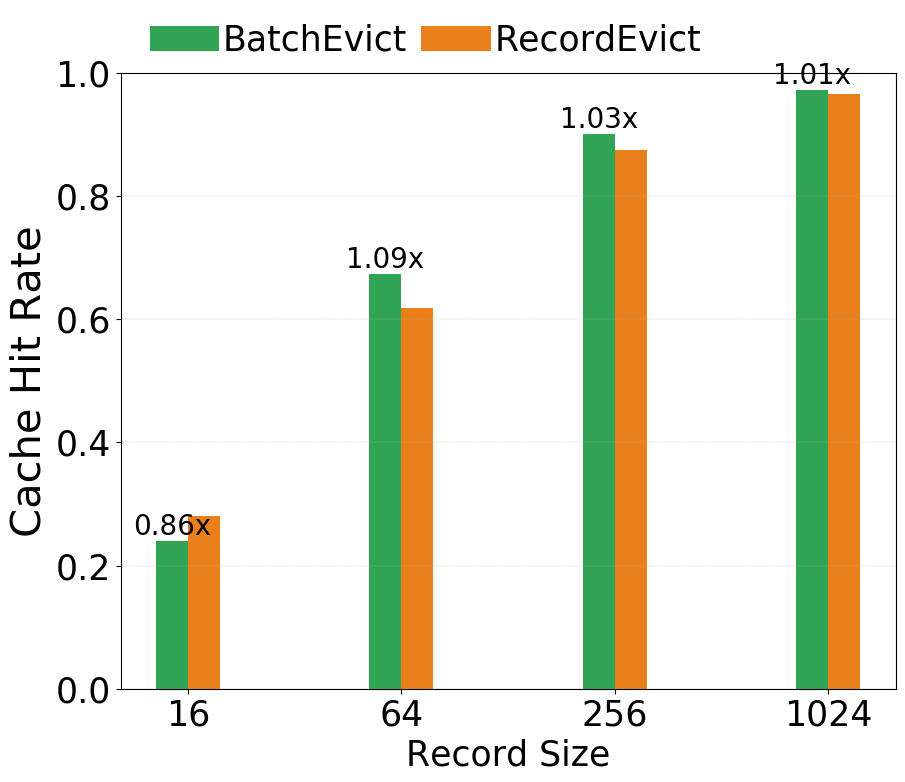

In [18]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from process_helper import select_color_idx

txtsize=30
ticksize=25

color_indices, line_colors = select_color_idx(4)
nemo_batch_evict_c = "#31a354"
nemo_record_evict_c =  "#ea801c"
# # page_retain_c = line_colors["BLUE"]
# page_evict_c = "#78c679"
# tt_retain_c = "#1f6f6f"
# tt_evict_c = "#54a1a1"

# nemo_batch_evict_label = "Nemo-BatchEvict"
# nemo_record_evict_label = "Nemo-RecordEvict"
nemo_batch_evict_label = "BatchEvict"
nemo_record_evict_label = "RecordEvict"

datadir = "../../output/"
exp_tuple_batch_evict = "exp_point_100m_batch"
exp_tuple_record_evict = "exp_point_100m_record"

# Load and prepare the data

data_tuple_batch = [json.loads(line) for line in open(datadir + exp_tuple_batch_evict + ".txt")]
df_tuple_batch = pd.DataFrame().from_records(data_tuple_batch).sort_values(by='g_record_size')

data_tuple_record = [json.loads(line) for line in open(datadir + exp_tuple_record_evict + ".txt")]
df_tuple_record = pd.DataFrame().from_records(data_tuple_record).sort_values(by='g_record_size')



fig, ax1 = plt.subplots(figsize=(10, 8))

bar_width = 0.15
indices = np.arange(len(data_tuple_batch))
offset = bar_width

# Bar chart for the primary data
batch_bars = ax1.bar(indices - offset/2 , df_tuple_batch["tuple_hit_rate_"], bar_width, label=nemo_batch_evict_label, color=nemo_batch_evict_c)
record_bars = ax1.bar(indices + offset/2, df_tuple_record["tuple_hit_rate_"], bar_width, label=nemo_record_evict_label, color=nemo_record_evict_c)

speedup = ((df_tuple_batch["tuple_hit_rate_"] / 
           df_tuple_record["tuple_hit_rate_"] ) )


for idx, (bar, gain) in enumerate(zip(batch_bars, speedup)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height,
            f'{gain:.2f}x',
            ha='center', va='bottom',
            fontsize=ticksize-5)


ax1.set_xticks(indices)
x_tick_num = df_tuple_batch["g_record_size"].astype(int)
x_tick_labels = x_tick_num 

ax1.set_xticklabels(x_tick_labels, fontsize=ticksize)
# ax1.set_yticklabels(fontsize=ticksize)
ax1.tick_params(axis='y', labelsize=ticksize)

# ax1.set_xscale('log')
# ax1.set_yscale('log')
# ax1.set_ylim(50, 200000)
ax1.set_ylim(0, 1)

ax1.set_ylabel("Cache Hit Rate", fontsize=txtsize)
# ax1.set_xlabel("Buffer Ratio (10GB, Write-heavy, Uniform Dist)", fontsize=txtsize)
ax1.set_xlabel("Record Size", fontsize=ticksize)
ax1.grid(axis='y', linestyle='--', linewidth=0.25)
# legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2, ncol=3, borderaxespad=0., handletextpad=0.4, labelspacing=0.2, columnspacing=0.5, frameon=False)

legend = ax1.legend(fontsize=ticksize, bbox_to_anchor=(0.02, 1, 1.1, .102), loc=2,
           ncol=3,borderaxespad=0., frameon=False,columnspacing=0.4, handletextpad=0.1)
# Legend
# ax1.legend(loc='upper left')

# plt.savefig("/home/hippo/Bonsai-private/paper/experiment/debug_eviction.pdf", bbox_inches='tight')




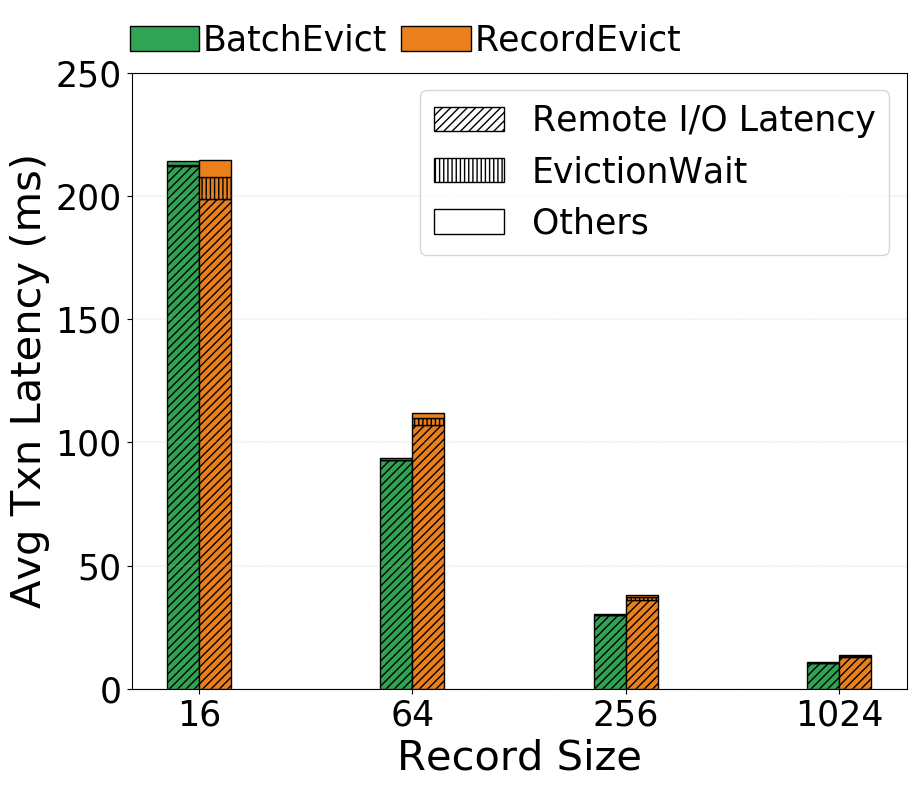

In [27]:
from matplotlib.patches import Patch
# fig, ax1 = plt.subplots(figsize=(12, 9.6))

txtsize=30
ticksize=25

color_indices, line_colors = select_color_idx(4)
nemo_batch_evict_c = "#31a354"
nemo_record_evict_c =  "#ea801c"
# # page_retain_c = line_colors["BLUE"]
# page_evict_c = "#78c679"
# tt_retain_c = "#1f6f6f"
# tt_evict_c = "#54a1a1"

# nemo_batch_evict_label = "Nemo-BatchEvict"
# nemo_record_evict_label = "Nemo-RecordEvict"
nemo_batch_evict_label = "BatchEvict"
nemo_record_evict_label = "RecordEvict"

datadir = "../../output/"
exp_tuple_batch_evict = "exp_point_100m_batch"
exp_tuple_record_evict = "exp_point_100m_record"

# Load and prepare the data
x_dimension= "g_record_size" 

data_tuple_batch = [json.loads(line) for line in open(datadir + exp_tuple_batch_evict + ".txt")]
df_tuple_batch = pd.DataFrame().from_records(data_tuple_batch).sort_values(by='g_record_size')

data_tuple_record = [json.loads(line) for line in open(datadir + exp_tuple_record_evict + ".txt")]
df_tuple_record = pd.DataFrame().from_records(data_tuple_record).sort_values(by='g_record_size')




fig, ax1 = plt.subplots(figsize=(10, 8))
offset = bar_width
# ax1 = fig.add_subplot(1, 1, 1)
index = np.arange(len(df_tuple_batch["g_record_size"])) - offset * 3
indices = np.arange(len(df_tuple_record))
dimension = "avg_sum_txn_latency (us)"
cur_label=nemo_batch_evict_label
cur_color=nemo_batch_evict_c
cur_df = df_tuple_batch 
cur_idx = 2
barloc = indices -(offset/2)

# ax1.bar(barloc, 
#         cur_df["avg_rw_abort_time_ (us)"]/1000.0 , width=bar_width,edgecolor='black', hatch='////',
#         color=cur_color,
#         label=cur_label+"-Abort-Time")
# ax1.bar(barloc, 
#         cur_exec_time/1000.0, bottom=cur_df["avg_rw_abort_time_ (us)"]/1000.0, width=bar_width, edgecolor='black',
#         color=cur_color,
#         label=cur_label+"-Execution-Time")
# ax1.bar(barloc, 
#         cur_df["avg_cc_time_ (us)"]/1000.0, bottom=[(i+j)/1000.0 for i, j in zip(cur_df["avg_rw_abort_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='||||',
#         color=cur_color,
#         label=cur_label+"-CC-Time")
# ax1.bar(barloc, 
#         cur_df["avg_log_time_ (us)"]/1000.0, bottom=[(i+j+m)/1000.0 for i, j, m in zip(cur_df["avg_rw_abort_time_ (us)"], cur_df["avg_cc_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='\\\\\\\\',
#         color=cur_color,
#         label=cur_label+"-Log-Time")



cur_exec_time = cur_df["avg_sum_rw_txn_latency (us)"] - cur_df["avg_remote_io_time_ (us)"] - cur_df["avg_rw_await_evict_time_ (us)"] 

ax1.bar(barloc, 
        cur_df["avg_remote_io_time_ (us)"]/1000.0 , width=bar_width,edgecolor='black', hatch='////',
        color=cur_color,
        label=cur_label+"-Abort-Time")
ax1.bar(barloc, 
        cur_df["avg_rw_await_evict_time_ (us)"]/1000.0, bottom=cur_df["avg_remote_io_time_ (us)"]/1000.0, width=bar_width, edgecolor='black',hatch='||||',
        color=cur_color,
        label=cur_label+"-Execution-Time")
ax1.bar(barloc, 
        cur_exec_time/1000.0, bottom=[(i+j)/1000.0 for i, j in zip( cur_df["avg_remote_io_time_ (us)"], cur_df["avg_rw_await_evict_time_ (us)"])], width=bar_width, edgecolor='black', 
        color=cur_color,
        label=cur_label+"-CC-Time")



cur_label=nemo_record_evict_label
cur_color=nemo_record_evict_c
cur_df = df_tuple_record 
cur_exec_time = cur_df["avg_sum_rw_txn_latency (us)"] - cur_df["avg_remote_io_time_ (us)"] - cur_df["avg_rw_await_evict_time_ (us)"] 
cur_idx = 4
barloc = indices+ (offset/2)

ax1.bar(barloc, 
        cur_df["avg_remote_io_time_ (us)"]/1000.0 , width=bar_width,edgecolor='black', hatch='////',
        color=cur_color,
        label=cur_label+"-Abort-Time")
ax1.bar(barloc, 
        cur_df["avg_rw_await_evict_time_ (us)"]/1000.0, bottom=cur_df["avg_remote_io_time_ (us)"]/1000.0, width=bar_width, edgecolor='black',hatch='||||',
        color=cur_color,
        label=cur_label+"-Execution-Time")
ax1.bar(barloc, 
        cur_exec_time/1000.0, bottom=[(i+j)/1000.0 for i, j in zip( cur_df["avg_remote_io_time_ (us)"], cur_df["avg_rw_await_evict_time_ (us)"])], width=bar_width, edgecolor='black',
        color=cur_color,
        label=cur_label+"-CC-Time")




# location = "upper left"
location = "best"
# ax1.legend(loc=location, frameon=False)
ax1.set_ylabel("Avg Txn Latency (ms)", fontsize=txtsize)
ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
ax1.set_xlabel("Record Size", fontsize=txtsize)


ax1.set_xticks(indices)
ax1.set_xticklabels(df_tuple_batch[x_dimension])
# ax1.set_xscale('log')
# ax1.set_yscale('log')
ax1.tick_params(axis='both', labelsize=ticksize)

subcategories = ['Remote I/O Latency', 'EvictionWait', 'Others']  # Stacks within each bar
bar_labels = [ nemo_batch_evict_label, nemo_record_evict_label]  # Bars within each group


# Colors for the bars (categories)
colors = [nemo_batch_evict_c, nemo_record_evict_c]

# Hatches for the subcategories
hatches = ['////', '||||', '']

# Create custom patches for the subcategories
hatch_patches = [Patch(facecolor='white', edgecolor='black', hatch=h, label=sc)
                 for h, sc in zip(hatches, subcategories)]

# Create custom patches for the categories
color_patches = [Patch(facecolor=c, edgecolor='black', label=bl)
                 for c, bl in zip(colors, bar_labels)]
ax1.set_ylim(0, 250)

# Create legends
subcat_legend = plt.legend(ncol=1, handles=hatch_patches,fontsize=ticksize, loc="upper right",)
ax1.add_artist(subcat_legend)  # Add the first legend manually to keep it when adding the second
# plt.legend(handles=color_patches, bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2,
#            ncol=3,borderaxespad=0.,handletextpad=0.4,labelspacing=0.2, columnspacing=0.5, frameon=False)
legend = plt.legend(handles=color_patches, fontsize=ticksize, bbox_to_anchor=(-0.02, 1.0, 1.1, .102), loc=2,
           ncol=3,borderaxespad=0., frameon=False,columnspacing=0.4, handletextpad=0.1)


